# Laboratorio 7: Spark MLlib

## Inciso 5. Pipeline de regresion lineal

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

**Datos.** Igual que en el inciso 4, se lee `processed/eneic_2025.parquet` (asalariados de 2025 ya filtrados). Si no existe, `datos.cargar` lo reconstruye desde los Excel de esta carpeta. El primer trimestre de 2026 no se toca en este cuaderno: queda reservado para la evaluacion final del inciso 7.

**Tarea.** Estimar `salario_mensual` (quetzales, sin transformar) con exactamente seis predictores: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml import PipelineModel
from pyspark.ml.regression import LinearRegression
from pyspark.sql import functions as F

from src import config, datos, modelos

config.preparar_directorios()
pd.set_option("display.float_format", "{:,.3f}".format)

spark = datos.iniciar_spark()
df = datos.cargar(spark, 2025)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


### 5.1 Entrenamiento y validacion

La division sigue la tabla del enunciado: los trimestres I, II y III de 2025 son entrenamiento y el IV de 2025 es validacion. Es una division temporal y no aleatoria a proposito: el modelo se va a usar para estimar salarios de un periodo posterior (2026), asi que la validacion tambien debe ser un periodo que el modelo no vio. Una particion aleatoria mezclaria registros del mismo trimestre en ambos lados y daria una idea demasiado optimista.

Todas las etapas del pipeline (indices de categorias, codificacion, estandarizacion y coeficientes) se ajustan solo con entrenamiento.

In [2]:
train, valid = modelos.dividir(df)
train, valid = train.cache(), valid.cache()

print("Entrenamiento (2025T1-T3):", train.count())
print("Validacion (2025T4):", valid.count())
train.groupBy("periodo_archivo").count().orderBy("periodo_archivo").show()

Entrenamiento (2025T1-T3): 40361
Validacion (2025T4): 12664


+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|13419|
|         2025T2|13492|
|         2025T3|13450|
+---------------+-----+



### 5.2 Modelo de referencia

El modelo de referencia predice para todas las personas el salario medio de entrenamiento. No usa ningun predictor, asi que marca el piso: un modelo que no le gane no aporta nada. Su R2 en validacion queda cerca de 0 por construccion (es ligeramente negativo porque la media de validacion no es exactamente la de entrenamiento).

In [3]:
pred_ref, media_train = modelos.predecir_referencia(train, valid)
metricas_ref = modelos.metricas(pred_ref)
print(f"Salario medio de entrenamiento: Q{media_train:,.2f}")
pd.DataFrame([metricas_ref], index=["referencia"])

Salario medio de entrenamiento: Q3,383.12


,mae,rmse,r2
referencia,"1,672.503","2,889.571",-0.003


### 5.3 Pipeline

El pipeline se arma en `src/modelos.py` para que el Random Forest del inciso 6 use exactamente la misma codificacion:

a. **Categoricas.** `StringIndexer` convierte cada codigo (`nivel_educativo`, `categoria_ocupacional`, `dominio`) en un indice y `OneHotEncoder` lo vuelve un vector de indicadoras. El indexador usa `handleInvalid="keep"`: si en validacion o en 2026 aparece un codigo que no estaba en entrenamiento (por ejemplo `DESCONOCIDO`), recibe un indice reservado que el codificador deja como vector de ceros, en lugar de fallar o de descartar la fila.

b. **VectorAssembler.** Junta `edad`, `antiguedad` y `horas_semanales` con las tres categoricas codificadas en un solo vector `features` de 18 posiciones.

c. **Estandarizacion.** Se usa la opcion interna `standardization=True` de `LinearRegression`. Spark escala cada predictor antes de optimizar, de modo que la penalizacion trate igual a todas las variables, y devuelve los coeficientes ya en las unidades originales (quetzales por anio, por hora, etc.). Por eso no se agrega un `StandardScaler`.

d. **Modelo.** `LinearRegression` sobre `salario_mensual` en quetzales.

**Regularizacion.** `regParam` es la fuerza de la penalizacion y `elasticNetParam` su tipo: 0 es Ridge (L2, encoge coeficientes), 1 es Lasso (L1, puede volverlos 0) y 0.5 es una mezcla. Se prueba una grilla con `regParam` en 0, 1, 10, 100, 500 y 1000 y los tres tipos, 16 configuraciones en total (con `regParam = 0` el tipo no importa y se prueba una sola vez). Se elige la de menor RMSE de validacion.

In [4]:
ejemplo = modelos.pipeline_regresion(LinearRegression(featuresCol="features", labelCol=config.OBJETIVO))
for etapa in ejemplo.getStages():
    print(type(etapa).__name__)

StringIndexer
OneHotEncoder
VectorAssembler
LinearRegression


In [5]:
REG_PARAMS = [0.0, 1.0, 10.0, 100.0, 500.0, 1000.0]
TIPOS = [0.0, 0.5, 1.0]
configuraciones = [{"regParam": 0.0, "elasticNetParam": 0.0}] + [
    {"regParam": r, "elasticNetParam": a} for r in REG_PARAMS[1:] for a in TIPOS
]


def construir_lineal(params):
    """LinearRegression con estandarizacion interna y la regularizacion indicada."""
    return LinearRegression(featuresCol="features", labelCol=config.OBJETIVO,
                            standardization=True, maxIter=100, **params)


grilla, ajustados = modelos.ajustar_grilla(train, valid, configuraciones, construir_lineal)
grilla["coef_en_cero"] = [sum(1 for c in ajustados[i].stages[-1].coefficients if c == 0)
                          for i in grilla["config"]]
grilla.sort_values("rmse_valid")

,config,regParam,elasticNetParam,rmse_train,mae_valid,rmse_valid,r2_valid,coef_en_cero
0,0,0.000,0.000,"2,245.293","1,210.137","2,186.420",0.426,0
1,1,1.000,0.000,"2,245.293","1,210.090","2,186.432",0.426,0
2,2,1.000,0.500,"2,245.294","1,209.853","2,186.470",0.426,0
3,3,1.000,1.000,"2,245.294","1,209.764","2,186.483",0.426,1
4,4,10.000,0.000,"2,245.297","1,209.670","2,186.551",0.426,0
5,5,10.000,0.500,"2,245.362","1,207.806","2,186.891",0.425,1
6,6,10.000,1.000,"2,245.512","1,206.184","2,187.291",0.425,3
7,7,100.000,0.000,"2,245.692","1,205.931","2,188.062",0.425,0
8,8,100.000,0.500,"2,251.988","1,195.802","2,197.019",0.420,5
10,10,500.000,0.000,"2,253.160","1,197.461","2,199.875",0.419,0


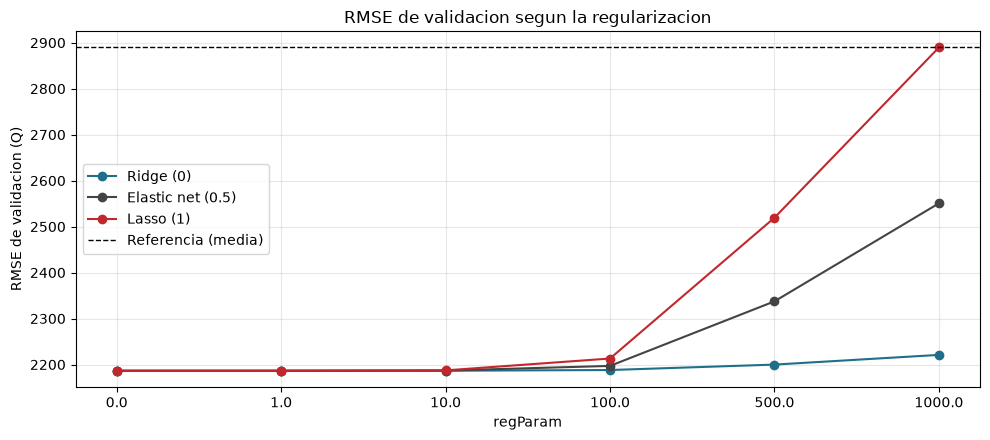

In [6]:
fig, eje = plt.subplots(figsize=(10, 4.5))
posiciones = range(len(REG_PARAMS))
for tipo, color, nombre in [(0.0, config.COLORES["principal"], "Ridge (0)"),
                            (0.5, config.COLORES["gris"], "Elastic net (0.5)"),
                            (1.0, config.COLORES["modelo"], "Lasso (1)")]:
    puntos = grilla[(grilla["elasticNetParam"] == tipo) | (grilla["regParam"] == 0)]
    puntos = puntos.set_index("regParam").reindex(REG_PARAMS)
    eje.plot(posiciones, puntos["rmse_valid"], marker="o", color=color, label=nombre)
eje.axhline(metricas_ref["rmse"], color="black", linestyle="--", linewidth=1, label="Referencia (media)")
eje.set_xticks(list(posiciones))
eje.set_xticklabels([str(r) for r in REG_PARAMS])
eje.set_xlabel("regParam")
eje.set_ylabel("RMSE de validacion (Q)")
eje.set_title("RMSE de validacion segun la regularizacion")
eje.grid(alpha=0.3)
eje.legend()
fig.tight_layout()
fig.savefig(config.FIGURAS / "05_grilla_regularizacion.png", dpi=120)
plt.show()

**Lectura de la grilla.**

- Sin regularizacion el RMSE de validacion es Q2,186.42. Con Ridge suave (`regParam` 1) queda en Q2,186.43 y con 10 en Q2,186.55: hasta `regParam` 10 todas las configuraciones estan a menos de Q1 de diferencia. Con 40,361 registros y solo 18 columnas los coeficientes estan bien estimados y no hay mucho que sobreajustar; el RMSE de entrenamiento (Q2,245) ni siquiera es menor que el de validacion.
- La penalizacion fuerte empeora el modelo. Lasso con `regParam` 500 sube a Q2,519 y deja 13 coeficientes en cero; con 1000 los 18 coeficientes quedan en cero y el modelo es exactamente el de referencia (Q2,889.57). Ridge se degrada mas despacio (Q2,221 con 1000) porque encoge los coeficientes pero no los anula.
- El MAE se mueve al reves que el RMSE: el menor MAE (Q1,195.80) aparece con `regParam` 100 y elastic net 0.5, donde el RMSE ya subio a Q2,197. La penalizacion acerca las predicciones a la media, lo que ayuda en los salarios tipicos y perjudica en los altos, que pesan mucho mas en el RMSE.

**Configuracion elegida: `regParam = 0` (sin regularizacion)**, por tener el menor RMSE de validacion como pide el enunciado. En la practica empata con Ridge suave: con estos datos la regularizacion no hace falta.

In [7]:
mejor = grilla.loc[grilla["rmse_valid"].idxmin()]
MEJOR_PARAMS = {"regParam": float(mejor["regParam"]), "elasticNetParam": float(mejor["elasticNetParam"])}
modelo_final = ajustados[int(mejor["config"])]
pred_valid = modelo_final.transform(valid).cache()
metricas_lineal = modelos.metricas(pred_valid)

print("Configuracion elegida:", MEJOR_PARAMS)
comparacion = pd.DataFrame([metricas_ref, metricas_lineal], index=["referencia", "regresion lineal"])
comparacion.loc["mejora (%)"] = [
    100 * (1 - metricas_lineal["mae"] / metricas_ref["mae"]),
    100 * (1 - metricas_lineal["rmse"] / metricas_ref["rmse"]),
    float("nan"),
]
comparacion

Configuracion elegida: {'regParam': 0.0, 'elasticNetParam': 0.0}


,mae,rmse,r2
referencia,"1,672.503","2,889.571",-0.003
regresion lineal,"1,210.137","2,186.420",0.426
mejora (%),27.645,24.334,NaN


**Frente a la referencia.** En 2025T4 la regresion lineal baja el MAE de Q1,672.50 a Q1,210.14 (27.6% menos) y el RMSE de Q2,889.57 a Q2,186.42 (24.3% menos). El R2 pasa de -0.003 a 0.426: los seis predictores explican cerca del 43% de la variacion del salario en validacion. Los predictores si contienen informacion sobre el salario.

Aun asi, el error tipico sigue siendo grande: Q1,210 de error absoluto medio frente a un salario mediano de Q3,000 en 2025, alrededor del 40%. Ademas el RMSE es casi el doble del MAE, senal de que unos pocos errores muy grandes pesan mucho (se revisa en 5.5). El 57% restante de la variacion depende de cosas que estos seis predictores no capturan, como la ocupacion especifica, la rama de actividad o el tamanio de la empresa.

### 5.4 Coeficientes

Los coeficientes estan en quetzales por unidad del predictor. Como cada variable categorica tiene una columna por categoria observada (no se elimina una categoria de referencia), el nivel absoluto de cada coeficiente categorico se comparte con el intercepto. Lo que si se puede leer es la **diferencia entre categorias de una misma variable**. Todo es asociacion con los demas predictores fijos, no un efecto causal.

In [8]:
lineal = modelo_final.stages[-1]
coeficientes = pd.DataFrame({"variable": modelos.nombres_features(modelo_final),
                             "coeficiente": list(lineal.coefficients)})


def etiqueta(nombre):
    """Traduce 'nivel_educativo=5' a 'nivel_educativo: Superior'."""
    if "=" not in nombre:
        return nombre
    columna, codigo = nombre.split("=")
    return f"{columna}: {config.ETIQUETAS[columna].get(codigo, codigo)}"


coeficientes["variable"] = coeficientes["variable"].map(etiqueta)
print(f"Intercepto: {lineal.intercept:,.1f}")
coeficientes

Intercepto: 1,775.5


,variable,coeficiente
0,edad,20.428
1,antiguedad,23.371
2,horas_semanales,16.167
3,nivel_educativo: Ninguno,"-1,250.902"
4,nivel_educativo: Preprimaria,-966.575
5,nivel_educativo: Primaria,-753.934
6,nivel_educativo: Basico,-548.723
7,nivel_educativo: Diversificado,82.494
8,nivel_educativo: Superior,"1,776.886"
9,nivel_educativo: Maestria,"6,863.059"


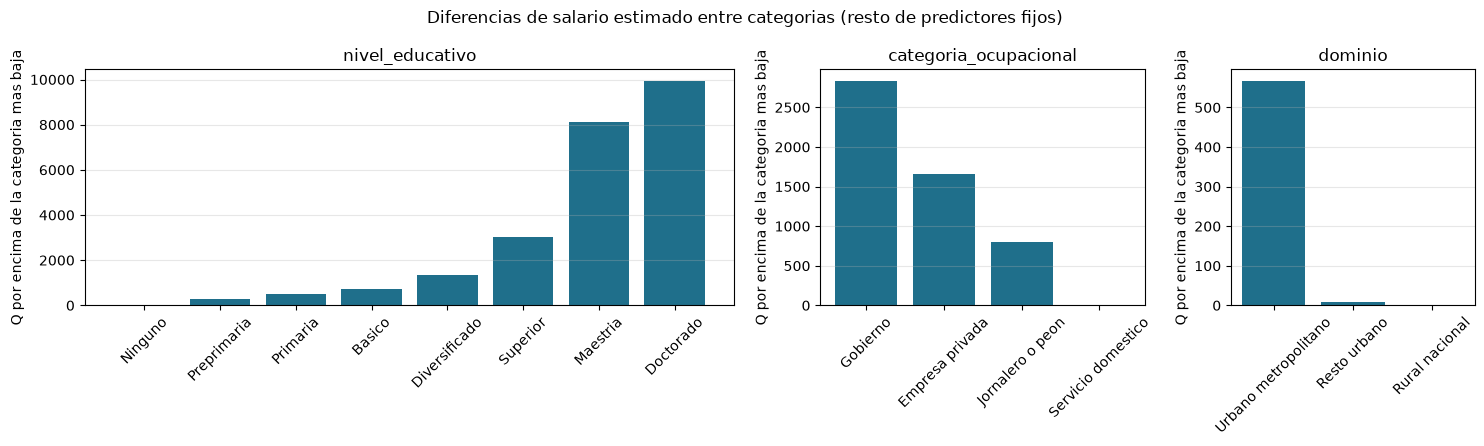

In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={"width_ratios": [8, 4, 3]})
for eje, columna in zip(ejes, config.CATEGORICAS):
    parte = coeficientes[coeficientes["variable"].str.startswith(columna)].copy()
    parte["categoria"] = parte["variable"].str.split(": ").str[1]
    parte["diferencia"] = parte["coeficiente"] - parte["coeficiente"].min()
    eje.bar(parte["categoria"], parte["diferencia"], color=config.COLORES["principal"])
    eje.set_title(columna)
    eje.set_ylabel("Q por encima de la categoria mas baja")
    eje.tick_params(axis="x", rotation=45)
    eje.grid(axis="y", alpha=0.3)
fig.suptitle("Diferencias de salario estimado entre categorias (resto de predictores fijos)")
fig.tight_layout()
fig.savefig(config.FIGURAS / "05_coeficientes_categoricos.png", dpi=120)
plt.show()

**Lectura de los coeficientes** (manteniendo fijos los demas predictores):

- **Numericas.** Cada anio de edad suma Q20.4, cada anio de antiguedad Q23.4 y cada hora semanal habitual Q16.2. Son efectos chicos frente a los categoricos: diez anios mas de antiguedad equivalen a unos Q234.
- **Educacion** es el predictor con mas peso. Entre ninguno y basico la diferencia es de solo Q702, pero los saltos grandes aparecen al final: superior sobre diversificado Q1,694, maestria sobre superior Q5,086 y doctorado sobre ninguno Q9,953. El coeficiente de doctorado se apoya en muy pocos casos (60 registros en todo 2025), asi que es el menos estable.
- **Categoria ocupacional.** Gobierno queda Q1,174 por encima de empresa privada y Q2,838 por encima del servicio domestico, que es la categoria mas baja.
- **Dominio.** El area urbana metropolitana tiene unos Q560 mas que el resto urbano y el rural, que practicamente no se distinguen entre si (Q9 de diferencia).

El modelo supone que cada efecto es lineal y aditivo: una hora mas vale lo mismo para cualquier persona y el premio educativo es igual en el campo y en la ciudad. El Random Forest del inciso 6 no necesita ese supuesto.

### 5.5 Influencia de los salarios extremos

El enunciado pide no recortar salarios altos. Para entender cuanto pesan en las metricas se mide que parte del error cuadratico total de validacion viene del 1% de salarios mas altos, y cuantas predicciones quedan negativas (algo que un modelo lineal puede producir aunque no tenga sentido para un salario). Esto no cambia las metricas principales, solo ayuda a leerlas.

In [10]:
p99 = valid.approxQuantile(config.OBJETIVO, [0.99], 0.0)[0]
errores = pred_valid.withColumn("error2", (F.col(config.OBJETIVO) - F.col("prediction")) ** 2)
total = errores.agg(F.sum("error2")).first()[0]
extremos = errores.filter(F.col(config.OBJETIVO) > p99).agg(F.count("*"), F.sum("error2")).first()

print(f"Percentil 99 del salario en validacion: Q{p99:,.0f}")
print(f"Registros por encima: {extremos[0]} de {valid.count()}")
print(f"Parte del error cuadratico total que aportan: {100 * extremos[1] / total:.1f}%")
pred_valid.agg(F.min("prediction").alias("prediccion_min"),
               F.max("prediction").alias("prediccion_max"),
               F.sum((F.col("prediction") < 0).cast("int")).alias("predicciones_negativas")).show()

Percentil 99 del salario en validacion: Q15,000
Registros por encima: 90 de 12664
Parte del error cuadratico total que aportan: 44.3%
+------------------+------------------+----------------------+
|    prediccion_min|    prediccion_max|predicciones_negativas|
+------------------+------------------+----------------------+
|-602.1074459294998|14933.459690175085|                    30|
+------------------+------------------+----------------------+



**Lectura.** En validacion, el percentil 99 del salario es Q15,000. Los 90 registros que lo superan (0.7% de 12,664) aportan el 44.3% del error cuadratico total. El modelo no alcanza esos salarios, su prediccion maxima es Q14,933, y por eso el RMSE queda casi al doble del MAE: el RMSE esta dominado por unos pocos salarios muy altos que el modelo subestima, mientras que el MAE refleja mejor el error de la mayoria.

Ademas, 30 predicciones son negativas (la minima es de -Q602). Una recta puede cruzar el cero en perfiles de pocas horas y baja escolaridad, lo que no tiene sentido para un salario. Los extremos se mantienen en la evaluacion, como pide el enunciado; el inciso 8 analiza el error por percentil de salario sobre 2026.

### 5.6 Guardar el mejor modelo

Se guarda el `PipelineModel` completo (codificacion y regresion, ajustado con 2025T1-T3) en `modelos/regresion_lineal`, junto con un JSON con la configuracion elegida y sus metricas de validacion. El inciso 7 reentrena esta misma configuracion con todo 2025 antes de evaluar en 2026.

In [11]:
ruta_modelo = config.MODELOS / "regresion_lineal"
modelos.guardar_modelo(modelo_final, ruta_modelo)

resumen = {
    "modelo": "LinearRegression",
    "entrenamiento": modelos.PERIODOS_TRAIN,
    "validacion": modelos.PERIODO_VALID,
    "parametros": {**MEJOR_PARAMS, "standardization": True, "maxIter": 100},
    "metricas_validacion": metricas_lineal,
    "metricas_referencia": metricas_ref,
}
(config.MODELOS / "regresion_lineal.json").write_text(json.dumps(resumen, indent=2))

cargado = PipelineModel.load(str(ruta_modelo))
print("RMSE del modelo cargado:", round(modelos.metricas(cargado.transform(valid))["rmse"], 3))
print(json.dumps(resumen, indent=2))

RMSE del modelo cargado: 2186.42
{
  "modelo": "LinearRegression",
  "entrenamiento": [
    "2025T1",
    "2025T2",
    "2025T3"
  ],
  "validacion": "2025T4",
  "parametros": {
    "regParam": 0.0,
    "elasticNetParam": 0.0,
    "standardization": true,
    "maxIter": 100
  },
  "metricas_validacion": {
    "mae": 1210.1374804326156,
    "rmse": 2186.419578668229,
    "r2": 0.4256745540389756
  },
  "metricas_referencia": {
    "mae": 1672.5026056435038,
    "rmse": 2889.5714322659232,
    "r2": -0.003131603852470688
  }
}


### 5.7 Conclusion del inciso 5

- El pipeline (`StringIndexer` y `OneHotEncoder` para las tres categoricas, `VectorAssembler` de 18 posiciones, estandarizacion interna y `LinearRegression`) se ajusto solo con 2025T1-T3 (40,361 registros) y se valido en 2025T4 (12,664).
- De 16 configuraciones de regularizacion gano `regParam = 0` con RMSE de validacion de Q2,186.42. La regularizacion suave empata y la fuerte empeora el modelo hasta dejarlo igual a la referencia.
- Frente a predecir la media, el modelo reduce el RMSE 24.3% y el MAE 27.6%, con R2 de 0.426.
- La educacion es lo que mas se asocia con el salario, sobre todo los niveles superior y de posgrado; despues vienen la categoria ocupacional (gobierno arriba, servicio domestico abajo) y el dominio (premio metropolitano de unos Q560).
- Las limitaciones: el 57% de la variacion queda sin explicar, el 0.7% de salarios mas altos genera el 44% del error cuadratico, y hay predicciones negativas. Una relacion lineal y aditiva no capta interacciones ni no linealidades, que es lo que puede aportar el Random Forest del inciso 6.
- El mejor modelo queda guardado en `modelos/regresion_lineal` y su configuracion en `modelos/regresion_lineal.json`. 2026 no se uso.

In [12]:
spark.stop()